In [24]:
#IMPORTING LIBRARIES 
import pandas as pd
import numpy as np 
from datetime import datetime, timedelta


In [25]:
#DATASET SIZE
np.random.seed(42)
n_customers = 10000

In [26]:
#DEFINING BUSINESS CATEGORIES
plans = ["Basic", "Standard", "Premium", "Enterprise"]
regions = [
    "North America",
    "Europe",
    "Asia",
    "South America"
]

devices = ["Mobile", "Desktop", "Tablet"]

cancel_reasons = [
    "Too Expensive",
    "Low Usage",
    "Better Alternative",
    "Technical Issues",
    "Other"
]

In [27]:
# GENERATE RAW MESSY DATASET
data = pd.DataFrame({
    "customer_id": range(1, n_customers+1),
    "subscription_plan": np.random.choice(
        ["basic", "Basic", "STANDARD", "Premium", "enterprise"],
        n_customers
    ),
    "region": np.random.choice(
        ["North America", "NA", "Europe", "Asia", "South America"],
        n_customers
    ),
    "device_type": np.random.choice(
        ["Mobile", "Desktop", "Tablet",None],
        n_customers
    ),
    "usage_hours_per_week": np.random.randint(-3,20,n_customers),

    "support_tickets": np.random.choice(
        [0,1,2,3,4,np.nan],
        n_customers
    ),
    "customer_lifetime_month": np.random.randint(1,36,n_customers)
})

In [28]:
fees = {
    "Basic": 25,
    "Standard": 50,
    "Premium": 90,
    "Enterprise": 150
}

data["monthly_fee"] = data["subscription_plan"].str.title().map(fees)


In [29]:
data["total_revenue"] = (data["monthly_fee"] * data["customer_lifetime_month"])

In [30]:
churn_probability = (
    (data["usage_hours_per_week"] < 5).astype(int)*0.3 +
    (data["support_tickets"] > 2).astype(int)*0.2 +
    np.random.rand(n_customers)*0.5)
data["churn_flag"] = (churn_probability > 0.6).astype(int)

In [31]:
data["subscription_status"] = np.where(
    data["churn_flag"]==1, "Cancelled", "Active"
)

In [32]:
data["cancellation_reason"] = np.where(
    data["subscription_status"] == "Cancelled",
    np.random.choice(cancel_reasons, n_customers),
    "None"
)

In [33]:
duplicates = data.sample(50)
data = pd.concat([data, duplicates])

In [34]:
data.to_csv("../data/subscription_churn_raw.csv",index=False
           )

In [35]:
data.head()

,customer_id,subscription_plan,region,device_type,usage_hours_per_week,support_tickets,customer_lifetime_month,monthly_fee,total_revenue,churn_flag,subscription_status,cancellation_reason
0,1,Premium,NA,None,12,1.0,4,90,360,0,Active,None
1,2,enterprise,Asia,Desktop,3,4.0,11,150,1650,1,Cancelled,Too Expensive
2,3,STANDARD,South America,Mobile,11,1.0,15,50,750,0,Active,None
3,4,enterprise,Asia,None,19,1.0,18,150,2700,0,Active,None
4,5,enterprise,Asia,Mobile,-2,0.0,20,150,3000,0,Active,None


In [36]:
#DATA CLEANING & PREPARATION

In [38]:
#LOADING RAW DATA:
df = pd.read_csv("../data/subscription_churn_raw.csv")

df.head()

,customer_id,subscription_plan,region,device_type,usage_hours_per_week,support_tickets,customer_lifetime_month,monthly_fee,total_revenue,churn_flag,subscription_status,cancellation_reason
0,1,Premium,NaN,NaN,12,1.0,4,90,360,0,Active,NaN
1,2,enterprise,Asia,Desktop,3,4.0,11,150,1650,1,Cancelled,Too Expensive
2,3,STANDARD,South America,Mobile,11,1.0,15,50,750,0,Active,NaN
3,4,enterprise,Asia,NaN,19,1.0,18,150,2700,0,Active,NaN
4,5,enterprise,Asia,Mobile,-2,0.0,20,150,3000,0,Active,NaN


In [42]:
#FIND DATA TYPES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              10050 non-null  int64  
 1   subscription_plan        10050 non-null  object 
 2   region                   7986 non-null   object 
 3   device_type              7464 non-null   object 
 4   usage_hours_per_week     10050 non-null  int64  
 5   support_tickets          8344 non-null   float64
 6   customer_lifetime_month  10050 non-null  int64  
 7   monthly_fee              10050 non-null  int64  
 8   total_revenue            10050 non-null  int64  
 9   churn_flag               10050 non-null  int64  
 10  subscription_status      10050 non-null  object 
 11  cancellation_reason      2248 non-null   object 
dtypes: float64(1), int64(6), object(5)
memory usage: 942.3+ KB


In [43]:
#FINDING MISSING VALUES
df.isnull().sum()

customer_id                   0
subscription_plan             0
region                     2064
device_type                2586
usage_hours_per_week          0
support_tickets            1706
customer_lifetime_month       0
monthly_fee                   0
total_revenue                 0
churn_flag                    0
subscription_status           0
cancellation_reason        7802
dtype: int64

In [44]:
#DUPLICATE ROWS
df.duplicated().sum()

np.int64(50)

In [46]:
#REMOVING DUPLICATES
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [47]:
#FIXING MESSY DATA 

In [48]:
df["subscription_plan"] = df["subscription_plan"].str.title()
df["subscription_plan"].value_counts()

subscription_plan
Basic         4063
Enterprise    2019
Premium       1975
Standard      1943
Name: count, dtype: int64

In [50]:
df["region"] = df["region"].replace({"NA": "North America"})
df["region"].value_counts()

region
South America    2023
Asia             2002
North America    1994
Europe           1924
Name: count, dtype: int64

In [51]:
df["device_type"].fillna("Unknown", inplace=True)

df["support_tickets"].fillna(0, inplace=True)

In [52]:
df["usage_hours_per_week"] = df["usage_hours_per_week"].clip(lower=0)

In [53]:
#RECALCULATING FEE & REVENUE:

In [55]:
fees = {
    "Basic": 25,
    "Standard": 50,
    "Premium": 90,
    "Enterprise": 150
}

df["monthly_fee"] = df["subscription_plan"].map(fees)

In [56]:
df["total_revenue"] = (
    df["monthly_fee"] * df["customer_lifetime_month"])

df.isnull().sum()

customer_id                   0
subscription_plan             0
region                     2057
device_type                   0
usage_hours_per_week          0
support_tickets               0
customer_lifetime_month       0
monthly_fee                   0
total_revenue                 0
churn_flag                    0
subscription_status           0
cancellation_reason        7765
dtype: int64

In [57]:
df.describe()

,customer_id,usage_hours_per_week,support_tickets,customer_lifetime_month,monthly_fee,total_revenue,churn_flag
count,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,8.371900,1.65580,17.997200,67.932500,1225.508000,0.223500
std,2886.89568,6.249392,1.48113,10.104831,47.619216,1200.113276,0.416611
min,1.00000,0.000000,0.00000,1.000000,25.000000,25.000000,0.000000
25%,2500.75000,2.000000,0.00000,9.000000,25.000000,375.000000,0.000000
50%,5000.50000,8.000000,1.00000,18.000000,50.000000,750.000000,0.000000
75%,7500.25000,14.000000,3.00000,27.000000,90.000000,1650.000000,0.000000
max,10000.00000,19.000000,4.00000,35.000000,150.000000,5250.000000,1.000000


In [58]:
df.to_csv(
    "../data/subscription_churn_clean.csv",
    index=False
)

In [59]:
#EXPLORATORY DATA ANALYSIS:

In [61]:
df = pd.read_csv("../data/subscription_churn_clean.csv")
df.shape

(10000, 12)

In [62]:
df.head()

,customer_id,subscription_plan,region,device_type,usage_hours_per_week,support_tickets,customer_lifetime_month,monthly_fee,total_revenue,churn_flag,subscription_status,cancellation_reason
0,1,Premium,NaN,Unknown,12,1.0,4,90,360,0,Active,NaN
1,2,Enterprise,Asia,Desktop,3,4.0,11,150,1650,1,Cancelled,Too Expensive
2,3,Standard,South America,Mobile,11,1.0,15,50,750,0,Active,NaN
3,4,Enterprise,Asia,Unknown,19,1.0,18,150,2700,0,Active,NaN
4,5,Enterprise,Asia,Mobile,0,0.0,20,150,3000,0,Active,NaN


In [63]:
df.describe()

,customer_id,usage_hours_per_week,support_tickets,customer_lifetime_month,monthly_fee,total_revenue,churn_flag
count,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,8.371900,1.65580,17.997200,67.932500,1225.508000,0.223500
std,2886.89568,6.249392,1.48113,10.104831,47.619216,1200.113276,0.416611
min,1.00000,0.000000,0.00000,1.000000,25.000000,25.000000,0.000000
25%,2500.75000,2.000000,0.00000,9.000000,25.000000,375.000000,0.000000
50%,5000.50000,8.000000,1.00000,18.000000,50.000000,750.000000,0.000000
75%,7500.25000,14.000000,3.00000,27.000000,90.000000,1650.000000,0.000000
max,10000.00000,19.000000,4.00000,35.000000,150.000000,5250.000000,1.000000


In [64]:
#CHURN RATE ANALYSIS

In [65]:
churn_rate = df["churn_flag"].mean() * 100
churn_rate

np.float64(22.35)

In [67]:
plan_churn = df.groupby("subscription_plan")["churn_flag"].mean() * 100
plan_churn

subscription_plan
Basic         23.529412
Enterprise    21.842496
Premium       20.151899
Standard      22.645394
Name: churn_flag, dtype: float64

In [68]:
plan_churn.sort_values(ascending=False)

subscription_plan
Basic         23.529412
Standard      22.645394
Enterprise    21.842496
Premium       20.151899
Name: churn_flag, dtype: float64

In [69]:
region_churn = df.groupby("region")["churn_flag"].mean() * 100
region_churn.sort_values(ascending=False)

region
Asia             23.476523
Europe           22.557173
South America    22.540781
North America    22.266800
Name: churn_flag, dtype: float64

In [70]:
df.groupby("churn_flag")["usage_hours_per_week"].mean()

churn_flag
0    9.799742
1    3.411186
Name: usage_hours_per_week, dtype: float64

In [71]:
df.groupby("churn_flag")["support_tickets"].mean()

churn_flag
0    1.441211
1    2.401342
Name: support_tickets, dtype: float64

In [72]:
revenue_loss = df[df["churn_flag"] == 1]["total_revenue"].sum()
revenue_loss

np.int64(2685685)

In [73]:
df.groupby("subscription_plan")["total_revenue"].sum().sort_values(ascending=False)

subscription_plan
Enterprise    5517600
Premium       3145680
Basic         1820000
Standard      1771800
Name: total_revenue, dtype: int64

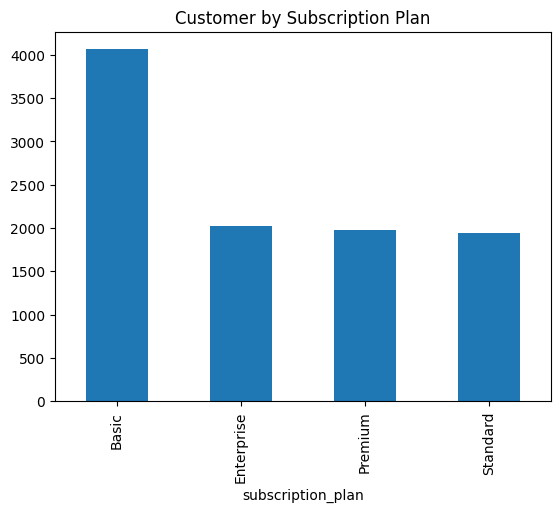

In [74]:
import matplotlib.pyplot as plt

df["subscription_plan"].value_counts().plot(kind="bar")
plt.title("Customer by Subscription Plan")
plt.show()